In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from tqdm import tqdm
import time
from qiskit.providers import JobStatus

In [2]:
# token = "" # IBM Quantum token here
 
# QiskitRuntimeService.save_account(
#   token=token,
#   channel="ibm_quantum" # `channel` distinguishes between different account types
# )

In [3]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=127)

sampler = Sampler(backend)

# debug with simulator
# backend = FakeAlmadenV2()
# sampler = Sampler(backend)

In [4]:
print(backend)

<IBMBackend('ibm_kyiv')>


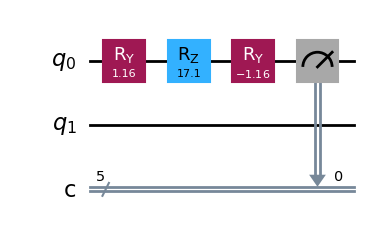

In [5]:
#Drawing the circuits for nu_e-->nu_e survival

#Assigning parameter values
theta=0.58
Dm2=7.49*10**-5 #eV^2
hbar= 6.582e-16 #eV.s
c=3e8 #m/s
L= 180e3 #Kamland baseline=180km converted to m
t=L/c #s
E_values= np.arange(2, 12, 0.5) # Energy range 2 MeV to 12 MeV
E=E_values[0]
omega=Dm2/(2*E*1e6*hbar) # Energy converted to eV
    
# implement the circuit

qc = QuantumCircuit(2, 5) # I took 2 qbits for 2 mass eigenststes. Initially both the qbits are at |0> which is nu_1. When we need to prepare nu_2, we will operate X gate on qbit1.

qc.ry(2*theta,0) # rotation matrix on y-axis = 2-D PMNS... prepares |nu_e>
qc.rz(omega*t,0) # Applying time evolution on nu_e
qc.ry(-2*theta,0) #reversing transformation to measure in flavour basis
qc.measure(0, 0)
    
qc.draw(output='mpl')
#plt.show()



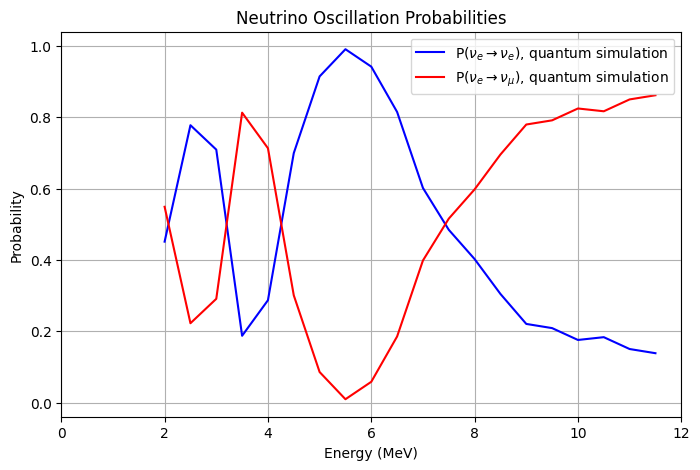

In [ ]:
# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []

for E in tqdm(E_values):
    omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    qc = QuantumCircuit(2, 1) # I took 2 qbits for 2 mass eigenststes. Initially both the qbits are at |0> which is nu_1. When we need to prepare nu_2, we will operate X gate on qbit1.

    qc.ry(2*theta,0) # rotation matrix on y-axis = 2-D PMNS... prepares |nu_e>
    qc.rz(omega*t,0) # Applying time evolution on nu_e
    qc.ry(-2*theta,0) #reversing transformation to measure in flavour basis
    qc.measure(0, 0)#measues in flavour basis
    
    ##### Run the circuit#######
    # initial_layout = [0, 1]
    # pqc = transpile(qc, backend=backend, initial_layout=initial_layout, optimization_level=1)
    # print(pqc.num_qubits)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    pmc = pm.run(qc)
    job = sampler.run([pmc], shots=512)

    print("Starting job", job.job_id())
    # print("Job status:", job.status())
    # while(job.status().name != "DONE"):
    #     time.sleep(10) # keep pulling for result
    #     print("Job status:", job.status())
    # print("job done")

    job_result = job.result()
    print("result received")

    counts = job_result[0].data.c.get_counts()
    print(counts)
    probability_nue=counts.get('0',0)/512 #nu_e-->nu_e survival probability
    probability_numu=counts.get('1',0)/512 #nu_e-->nu_mu pscillation probability

    # Store values
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)

    np.save('E_list.npy', E_list)
    np.save('P_nue_list.npy', P_nue_list)
    np.save('P_numu_list.npy', P_numu_list)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# # Load the classical GLoBES results from the file
# glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')

# # Plot classical GLoBES results from the data file
# plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
# plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
plt.xlabel("Energy (MeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.savefig('plots/ibm.pdf')
plt.savefig('plots/ibm.png')
plt.show()
    
   